<a href="https://colab.research.google.com/github/MontseR55/Problema-1/blob/main/tarea_problema1_codigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Optativa 1 — Problema 1: Análisis Térmico de una Batería de Ion-Litio
**Gestión Energética II | Primer Semestre 2026**

Resolución numérica de la ecuación de conducción transitoria 1D con generación interna de calor (Arrhenius), flujo solar y convección.

In [1]:
# ============================================================
# Importación de bibliotecas
# ============================================================

import numpy as np                        # operaciones numéricas y vectoriales
from scipy.integrate import solve_ivp     # integrador de EDOs
import matplotlib.pyplot as plt           # generación de gráficos
import warnings
warnings.filterwarnings('ignore')

# Tamaño gráficos
plt.rcParams.update({
    'figure.dpi'    : 130,
    'font.size'     : 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 2
})

print('✓ Bibliotecas cargadas correctamente')

✓ Bibliotecas cargadas correctamente


---
## Actividad 1 — Definición de parámetros

In [ ]:
# ============================================================
# Parámetros del problema (Actividad 1)
# ============================================================

# --- Propiedades térmicas de la batería ---
rho   = 2500.0    # [kg/m³]
cp    = 900.0     # [J/kg·K]
k     = 1.0       # [W/m·K]

# --- Geometría ---
L     = 0.01      # [m]

# --- Condiciones de contorno ---
h     = 10.0      # [W/m²·K]
T_inf = 298.15    # [K]
q_sol = 800.0     # [W/m²]

# --- Condición inicial ---
T0    = 298.15    # [K]

# --- Parámetros de generación interna ---
q0    = 1.0e6     # [W/m³]
Ea    = 20000.0   # [J/mol]
R_gas = 8.314     # [J/mol·K]

# --- Temperatura de referencia (linealización de Taylor) ---
Tr    = 298.15    # [K]

# --- Parámetros numéricos ---
N     = 51        # [-]
t_fin = 3600.0    # [s]

# --- Parámetros derivados de la linealización ---
qr    = q0 * np.exp(-Ea / (R_gas * Tr))              # [W/m³] q''' en Tr
beta  = qr * (Ea / (R_gas * Tr**2))                  # [W/m³·K] pendiente linealización

# --- Diagnóstico ---
alpha = k / (rho * cp)                               # difusividad térmica
dx    = L / (N - 1)
print('✓ Parámetros definidos')
print(f'   Difusividad térmica    α = {alpha:.2e} m²/s')
print(f'   Paso espacial         Δx = {dx*1000:.4f} mm')
print(f"   q''' en Tr (Arrhenius)   = {qr:.4f} W/m³")
print(f"   β (pendiente Taylor)    = {beta:.4f} W/(m³·K)")

✓ Parámetros definidos
   Difusividad térmica    α = 4.44e-07 m²/s
   Paso espacial         Δx = 0.2000 mm
   q''' en Tr (Arrhenius)   = 313.2973 W/m³
   β (pendiente Taylor)    = 8.4783 W/(m³·K)


---
## Actividades 2–5 — Discretización y simulación

In [ ]:
# ============================================================
# Discretización espacial y definición de la EDO
# ============================================================

x  = np.linspace(0, L, N)    # [m]  vector de posiciones x_0 ... x_{N-1}
dx = x[1] - x[0]             # [m]  paso espacial

# --- Función de generación interna: Arrhenius exacto ---
def q_gen_arrhenius(T_vec):
    """q'''(T) = q0 * exp(-Ea / R*T) [W/m³] — forma exacta"""
    return q0 * np.exp(-Ea / (R_gas * T_vec))

# --- Función de generación interna: linealización de Taylor ---
def q_gen_lineal(T_vec):
    """q'''(T) ≈ qr + β*(T - Tr) [W/m³] — aproximación de primer orden"""
    return qr + beta * (T_vec - Tr)

# Seleccionar cuál forma usar (cambiar aquí para comparar)
q_gen = q_gen_arrhenius     # <-- cambiar a q_gen_lineal para la versión linealizada

# --- Sistema de EDOs: dT/dt para todos los nodos ---
def dTdt(t, T):
    """
    Devuelve dT/dt para cada nodo usando diferencias finitas centradas.

    Ecuación a resolver (enunciado Ec. 3):
        ρ·cp · dT/dt = k · d²T/dx² + q'''(T)

    Condiciones de borde:
        x=0 (Ec. 7): -k·dT/dx = q''_sol - h·(T(0,t) - T_inf)
        x=L (Ec. 8): dT/dx = 0  (adiabático)
    """
    dT    = np.zeros(N)
    q_vol = q_gen(T)            # generación interna en cada nodo [W/m³]

    # Nodos interiores — diferencias finitas centradas
    i = np.arange(1, N - 1)
    d2T_int      = (T[i+1] - 2*T[i] + T[i-1]) / dx**2
    dT[i]        = alpha * d2T_int + q_vol[i] / (rho * cp)

    # Nodo en x=0: condición de borde con flujo solar y convección
    # El nodo fantasma T_{-1} se obtiene imponiendo el flujo exacto:
    #   -k (T_1 - T_{-1}) / (2*dx) = q''_sol - h*(T_0 - T_inf)
    flux_izq     = q_sol - h * (T[0] - T_inf)          # flujo neto entrante [W/m²]
    T_ghost_izq  = T[1] + 2 * dx * flux_izq / k        # nodo fantasma izquierdo
    d2T_0        = (T[1] - 2*T[0] + T_ghost_izq) / dx**2
    dT[0]        = alpha * d2T_0 + q_vol[0] / (rho * cp)

    # Nodo en x=L: adiabático — nodo fantasma = nodo interior adyacente
    T_ghost_der  = T[N-2]                               # nodo fantasma derecho
    d2T_N        = (T_ghost_der - 2*T[N-1] + T[N-2]) / dx**2
    dT[N-1]      = alpha * d2T_N + q_vol[N-1] / (rho * cp)

    return dT

print('✓ EDO definida con diferencias finitas centradas')
print(f'   Número de nodos: N = {N}   |   Δx = {dx*1000:.4f} mm')

✓ EDO definida con diferencias finitas centradas
   Número de nodos: N = 51   |   Δx = 0.2000 mm


In [ ]:
# ============================================================
# Ejecución de la simulación (Actividades 4 y 5)
# Método: solve_ivp con Runge-Kutta RK45 adaptativo
# ============================================================

T_init  = np.full(N, T0)                    # condición inicial uniforme
t_eval  = np.linspace(0, t_fin, 2000)       # instantes de tiempo para guardar

print(f'Ejecutando simulación...')
print(f'   Tiempo total : {t_fin:.0f} s  ({t_fin/60:.1f} min)')
print(f'   Nodos        : {N}')

sol = solve_ivp(
    fun     = dTdt,
    t_span  = (0.0, t_fin),
    y0      = T_init,
    method  = 'RK45',          # Runge-Kutta de orden 4-5 con paso adaptativo
    t_eval  = t_eval,
    rtol    = 1e-6,            # tolerancia relativa
    atol    = 1e-6,            # tolerancia absoluta
    max_step= 10.0             # paso máximo [s]
)

if sol.success:
    T_sol = sol.y   # shape (N, n_tiempos)
    t_sol = sol.t   # shape (n_tiempos,)
    print(f'✓ Simulación completada')
    print(f'   T inicial : {T_sol[:,0].mean()-273.15:.3f} °C')
    print(f'   T máx final: {T_sol[:,-1].max()-273.15:.3f} °C  (nodo {T_sol[:,-1].argmax()})')
else:
    print(f'✗ Error: {sol.message}')

Ejecutando simulación...
   Tiempo total : 3600 s  (60.0 min)
   Nodos        : 51
✓ Simulación completada
   T inicial : 25.000 °C
   T máx final: 89.309 °C  (nodo 0)


---
## Actividades 6–10 — Resultados y análisis

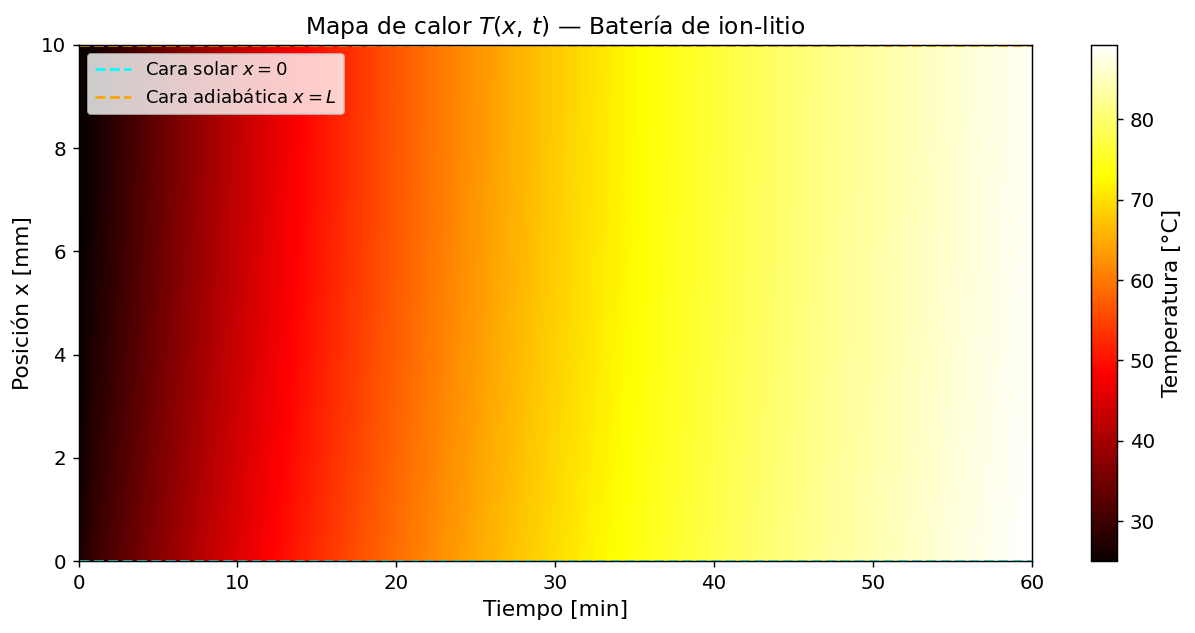

✓ Mapa de calor guardado como fig1_heatmap_Txt.png


In [ ]:
# ============================================================
# Gráfico 1: Mapa de calor T(x, t)  (Actividad 6)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

T_C   = T_sol - 273.15                           # convertir a °C
X_mm  = x * 1000                                 # posición en mm
t_min = t_sol / 60                               # tiempo en minutos

# pcolormesh requiere grillas 2D
TIME, X_GRID = np.meshgrid(t_min, X_mm)
pcm = ax.pcolormesh(TIME, X_GRID, T_C, cmap='hot', shading='auto')
cbar = fig.colorbar(pcm, ax=ax, label='Temperatura [°C]')

ax.set_xlabel('Tiempo [min]')
ax.set_ylabel('Posición x [mm]')
ax.set_title('Mapa de calor $T(x,\,t)$ — Batería de ion-litio')
ax.set_xlim(0, t_fin / 60)
ax.set_ylim(0, L * 1000)

# Indicar condiciones de borde en el gráfico
ax.axhline(y=0,        color='cyan',   lw=1.5, ls='--', label='Cara solar $x=0$')
ax.axhline(y=L*1000,   color='orange', lw=1.5, ls='--', label='Cara adiabática $x=L$')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('fig1_heatmap_Txt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Mapa de calor guardado como fig1_heatmap_Txt.png')

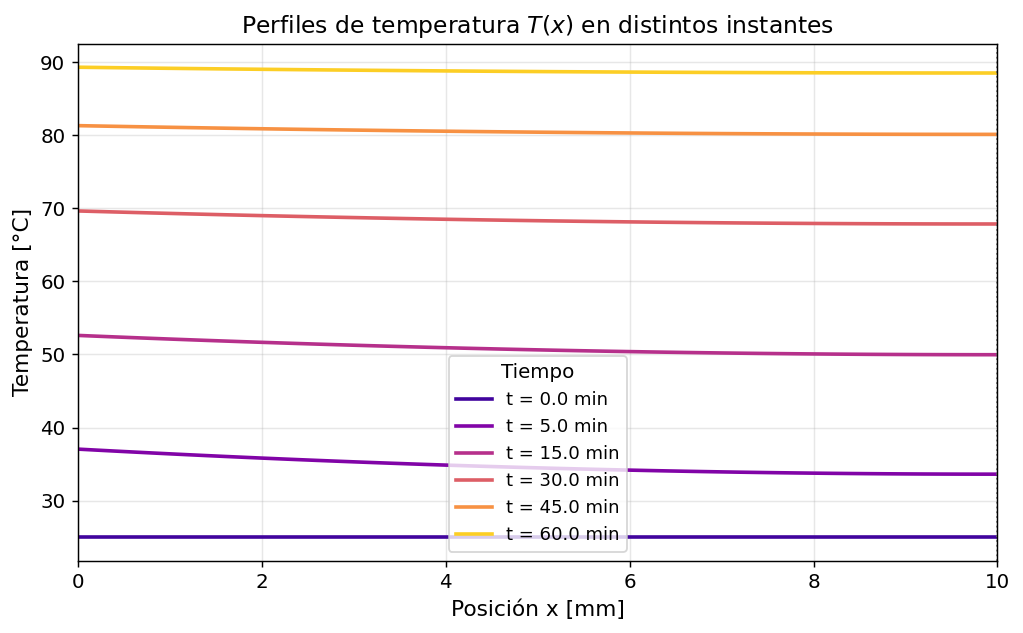

✓ Perfiles guardados como fig2_perfiles_Tx.png


In [ ]:
# ============================================================
# Gráfico 2: Perfiles T(x) en distintos tiempos
#           (Actividad 7 — mínimo 4 tiempos)
# ============================================================

t_targets = [0, 300, 900, 1800, 2700, 3600]    # [s] tiempos de interés
colores   = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_targets)))

fig, ax = plt.subplots(figsize=(8, 5))

for tc, col in zip(t_targets, colores):
    idx     = np.argmin(np.abs(t_sol - tc))     # índice de tiempo más cercano
    perfil  = T_sol[:, idx] - 273.15            # perfil en °C
    ax.plot(X_mm, perfil, color=col, label=f't = {tc/60:.1f} min')

ax.set_xlabel('Posición x [mm]')
ax.set_ylabel('Temperatura [°C]')
ax.set_title('Perfiles de temperatura $T(x)$ en distintos instantes')
ax.legend(title='Tiempo')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L * 1000)

# Marcar condiciones de borde
ax.axvline(x=0,        color='gray', lw=1, ls=':')
ax.axvline(x=L*1000,   color='gray', lw=1, ls=':', label='Cara adiabática')

plt.tight_layout()
plt.savefig('fig2_perfiles_Tx.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Perfiles guardados como fig2_perfiles_Tx.png')

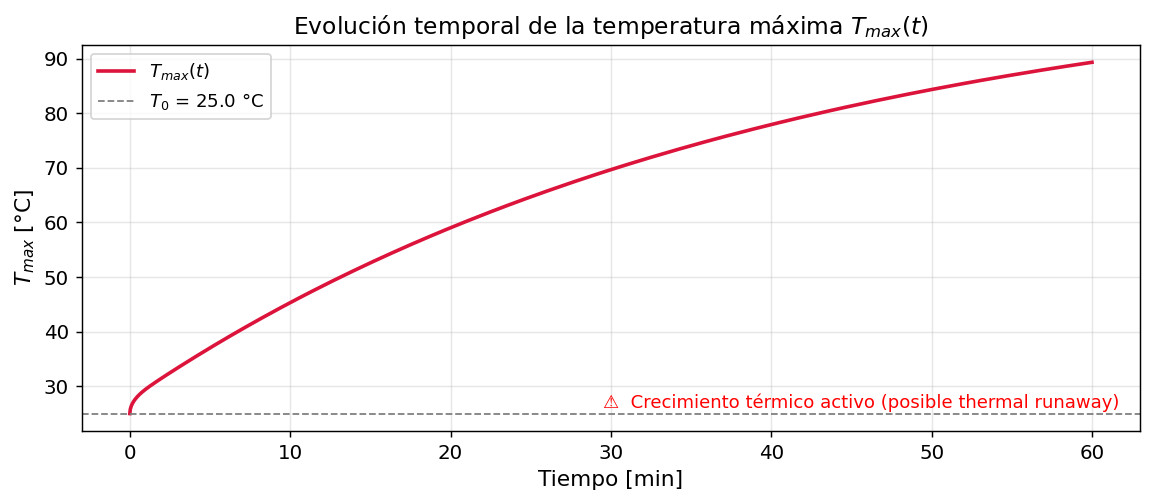

✓ Gráfico guardado como fig3_Tmax_t.png
   Tmax inicial : 25.000 °C
   Tmax final   : 89.309 °C
   ΔT últimos 100 pasos: 1.3525 °C  → ⚠  Crecimiento térmico activo (posible thermal runaway)


In [ ]:
# ============================================================
# Gráfico 3: Temperatura máxima Tmax(t)  (Actividad 8)
# ============================================================

T_max    = T_sol.max(axis=0) - 273.15    # máximo sobre todos los nodos en cada tiempo
idx_max  = T_sol.argmax(axis=0)          # índice del nodo con temperatura máxima
x_Tmax   = x[idx_max] * 1000            # posición de Tmax en mm

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_min, T_max, color='crimson', lw=2, label='$T_{max}(t)$')
ax.axhline(y=T0 - 273.15, color='gray', ls='--', lw=1, label=f'$T_0$ = {T0-273.15:.1f} °C')

ax.set_xlabel('Tiempo [min]')
ax.set_ylabel('$T_{max}$ [°C]')
ax.set_title('Evolución temporal de la temperatura máxima $T_{max}(t)$')
ax.grid(True, alpha=0.3)
ax.legend()

# Diagnóstico de estabilidad
delta_T_final = T_max[-1] - T_max[-100]
if delta_T_final > 1.0:
    estado = '⚠  Crecimiento térmico activo (posible thermal runaway)'
    color_txt = 'red'
else:
    estado = '✓  Sistema aproximadamente estable'
    color_txt = 'green'
ax.text(0.98, 0.05, estado, transform=ax.transAxes,
        ha='right', va='bottom', color=color_txt, fontsize=10)

plt.tight_layout()
plt.savefig('fig3_Tmax_t.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✓ Gráfico guardado como fig3_Tmax_t.png')
print(f'   Tmax inicial : {T_max[0]:.3f} °C')
print(f'   Tmax final   : {T_max[-1]:.3f} °C')
print(f'   ΔT últimos 100 pasos: {delta_T_final:.4f} °C  → {estado}')

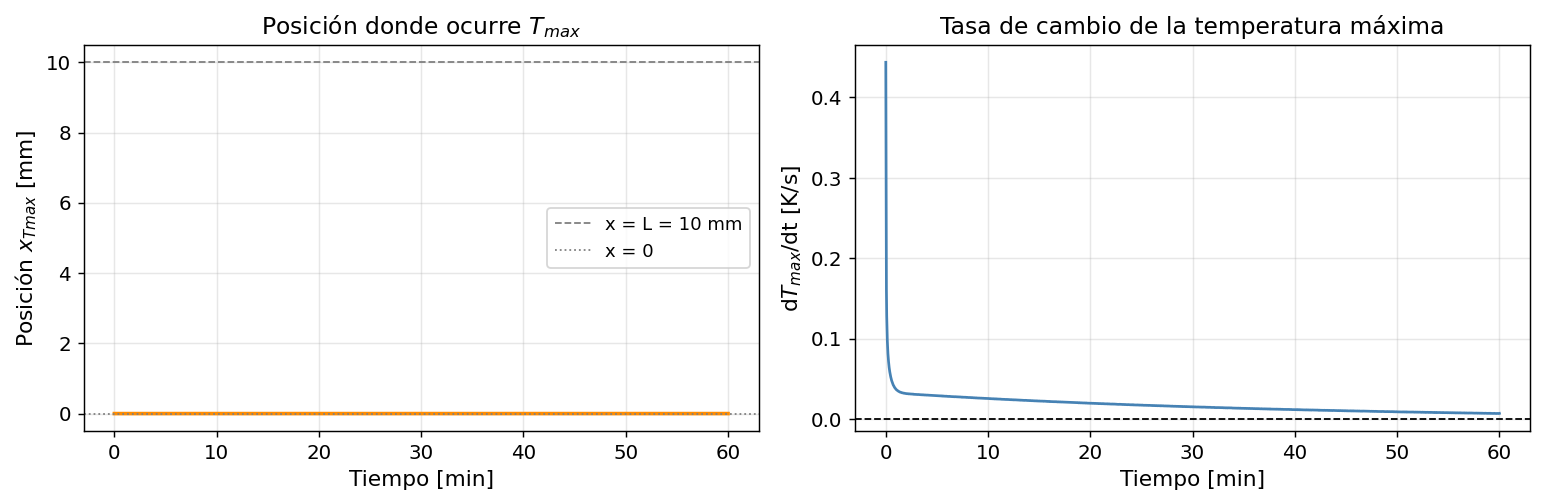

✓ Posición más frecuente de Tmax: nodo 0 → x = 0.000 mm


In [ ]:
# ============================================================
# Posición de Tmax y tasa de cambio  (Actividad 9)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico izquierdo: posición de Tmax
ax1.plot(t_min, x_Tmax, color='darkorange', lw=2)
ax1.axhline(y=L*1000, color='gray', ls='--', lw=1, label=f'x = L = {L*1000:.0f} mm')
ax1.axhline(y=0,      color='gray', ls=':',  lw=1, label='x = 0')
ax1.set_xlabel('Tiempo [min]')
ax1.set_ylabel('Posición $x_{Tmax}$ [mm]')
ax1.set_title('Posición donde ocurre $T_{max}$')
ax1.set_ylim(-0.5, L*1000 + 0.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico derecho: tasa de cambio dTmax/dt
dTmax_dt = np.gradient(T_sol.max(axis=0), t_sol)   # [K/s]
ax2.plot(t_min, dTmax_dt, color='steelblue', lw=1.5)
ax2.axhline(y=0, color='black', ls='--', lw=1)
ax2.set_xlabel('Tiempo [min]')
ax2.set_ylabel('d$T_{max}$/dt [K/s]')
ax2.set_title('Tasa de cambio de la temperatura máxima')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_posicion_Tmax.png', dpi=150, bbox_inches='tight')
plt.show()

nodo_mas_frecuente = np.bincount(idx_max).argmax()
print(f'✓ Posición más frecuente de Tmax: nodo {nodo_mas_frecuente} → x = {x[nodo_mas_frecuente]*1000:.3f} mm')

In [ ]:
# ============================================================
# Análisis de estabilidad térmica  (Actividad 10)
# ============================================================

# Comparar generación interna vs pérdidas convectivas al final de la simulación
T_final     = T_sol[:, -1]
Q_gen_total = q_gen(T_final).mean() * L                    # [W/m²] generación promedio
Q_conv      = h * (T_final[0] - T_inf)                    # [W/m²] pérdida convectiva
Q_neta      = Q_gen_total + q_sol - Q_conv                 # balance neto

print('=' * 55)
print('   ANÁLISIS DE ESTABILIDAD TÉRMICA (t = t_final)')
print('=' * 55)
print(f'   Generación interna media : {Q_gen_total:.4f} W/m²')
print(f'   Flujo solar              : {q_sol:.4f} W/m²')
print(f'   Pérdida convectiva       : {Q_conv:.4f} W/m²')
print(f'   Balance neto             : {Q_neta:.4f} W/m²')
print('-' * 55)
if Q_neta > 0.01:
    print('   → El sistema AÚN acumula calor: posible inestabilidad')
else:
    print('   → El sistema está cerca del equilibrio térmico')
print('=' * 55)

   ANÁLISIS DE ESTABILIDAD TÉRMICA (t = t_final)
   Generación interna media : 12.9864 W/m²
   Flujo solar              : 800.0000 W/m²
   Pérdida convectiva       : 643.0893 W/m²
   Balance neto             : 169.8971 W/m²
-------------------------------------------------------
   → El sistema AÚN acumula calor: posible inestabilidad


---
## Actividad 11 — Análisis paramétrico

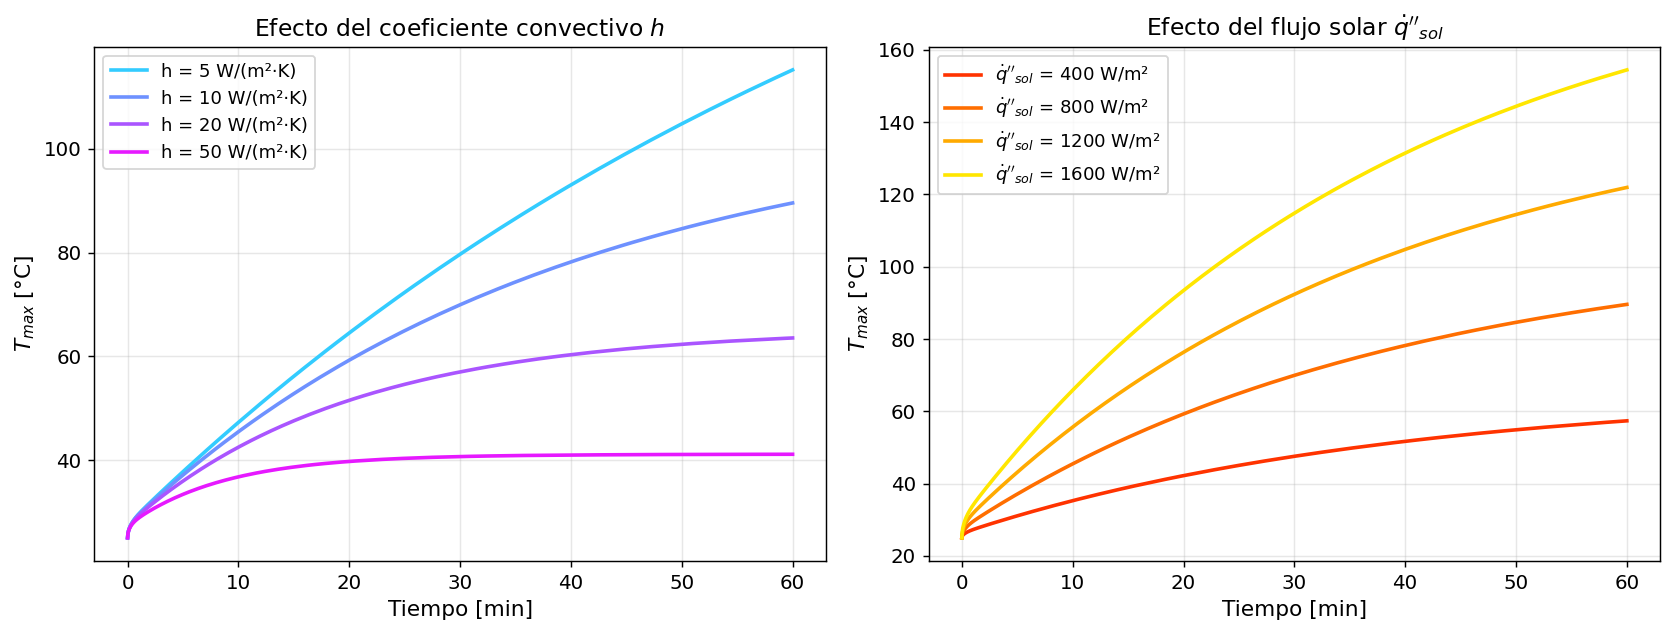

✓ Análisis paramétrico guardado como fig5_analisis_parametrico.png


In [ ]:
# ============================================================
# Análisis paramétrico  (Actividad 11)
# Se varía h (coef. convectivo) y q_sol (flujo solar)
# ============================================================

def simular_caso(h_val, q_sol_val, k_val=k):
    """
    Reutiliza la misma estructura de EDO para distintos parámetros.
    Devuelve (t_sol, T_max_t) para comparación.
    """
    alpha_p = k_val / (rho * cp)

    def _dTdt(t, T):
        dT    = np.zeros(N)
        q_vol = q_gen(T)
        i = np.arange(1, N - 1)
        dT[i] = alpha_p * (T[i+1] - 2*T[i] + T[i-1]) / dx**2 + q_vol[i] / (rho * cp)
        flux  = q_sol_val - h_val * (T[0] - T_inf)
        T_gl  = T[1] + 2 * dx * flux / k_val
        dT[0] = alpha_p * (T[1] - 2*T[0] + T_gl) / dx**2 + q_vol[0] / (rho * cp)
        dT[-1]= alpha_p * (T[-3] - 2*T[-1] + T[-2]) / dx**2 + q_vol[-1] / (rho * cp)
        return dT

    s = solve_ivp(_dTdt, (0, t_fin), np.full(N, T0),
                  method='RK45', t_eval=t_eval, rtol=1e-6, atol=1e-6, max_step=10.0)
    return s.t, s.y.max(axis=0) - 273.15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Efecto de h ---
h_valores = [5, 10, 20, 50]
colores_h = plt.cm.cool(np.linspace(0.2, 0.9, len(h_valores)))
for hv, col in zip(h_valores, colores_h):
    t_, Tmax_ = simular_caso(hv, q_sol)
    ax1.plot(t_/60, Tmax_, color=col, label=f'h = {hv} W/(m²·K)')
ax1.set_xlabel('Tiempo [min]')
ax1.set_ylabel('$T_{max}$ [°C]')
ax1.set_title('Efecto del coeficiente convectivo $h$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Efecto de q_sol ---
q_valores = [400, 800, 1200, 1600]
colores_q = plt.cm.autumn(np.linspace(0.2, 0.9, len(q_valores)))
for qv, col in zip(q_valores, colores_q):
    t_, Tmax_ = simular_caso(h, qv)
    ax2.plot(t_/60, Tmax_, color=col, label=f"$\\dot{{q}}''_{{sol}}$ = {qv} W/m²")
ax2.set_xlabel('Tiempo [min]')
ax2.set_ylabel('$T_{max}$ [°C]')
ax2.set_title("Efecto del flujo solar $\\dot{q}''_{sol}$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_analisis_parametrico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Análisis paramétrico guardado como fig5_analisis_parametrico.png')

In [ ]:
# ============================================================
# Tabla resumen de parámetros de la simulación
# ============================================================

print('=' * 65)
print(f'{"TABLA DE PARÁMETROS — SIMULACIÓN":^65}')
print('=' * 65)
print(f'{"Parámetro":<30} {"Símbolo":<12} {"Valor":<12} {"Unidad"}')
print('-' * 65)
params = [
    ('Densidad',                  'ρ',       rho,    'kg/m³'     ),
    ('Calor específico',          'cp',      cp,     'J/(kg·K)'  ),
    ('Conductividad térmica',     'k',       k,      'W/(m·K)'   ),
    ('Espesor',                   'L',       L,      'm'         ),
    ('Coef. convectivo',          'h',       h,      'W/(m²·K)'  ),
    ('Flujo solar',               'q_sol',   q_sol,  'W/m²'      ),
    ('Temperatura ambiente',      'T_inf',   T_inf,  'K'         ),
    ('Temperatura inicial',       'T0',      T0,     'K'         ),
    ('Factor preexponencial',     'q0',      q0,     'W/m³'      ),
    ('Energía de activación',     'Ea',      Ea,     'J/mol'     ),
    ('Constante de gases',        'R',       R_gas,  'J/(mol·K)' ),
    ('Temperatura de referencia', 'Tr',      Tr,     'K'         ),
    ('Nodos espaciales',          'N',       N,      '-'         ),
    ('Tiempo total simulación',   't_fin',   t_fin,  's'         ),
]
for nombre, simbolo, valor, unidad in params:
    print(f'  {nombre:<28} {simbolo:<12} {valor:<12.4g} {unidad}')
print('=' * 65)

                TABLA DE PARÁMETROS — SIMULACIÓN                 
Parámetro                      Símbolo      Valor        Unidad
-----------------------------------------------------------------
  Densidad                     ρ            2500         kg/m³
  Calor específico             cp           900          J/(kg·K)
  Conductividad térmica        k            1            W/(m·K)
  Espesor                      L            0.01         m
  Coef. convectivo             h            10           W/(m²·K)
  Flujo solar                  q_sol        800          W/m²
  Temperatura ambiente         T_inf        298.1        K
  Temperatura inicial          T0           298.1        K
  Factor preexponencial        q0           1e+06        W/m³
  Energía de activación        Ea           2e+04        J/mol
  Constante de gases           R            8.314        J/(mol·K)
  Temperatura de referencia    Tr           298.1        K
  Nodos espaciales             N            51        